In [1]:
import torch
from transformers import pipeline, BertTokenizer, BertForMaskedLM
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Setup complete!")

Setup complete!


In [2]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')
print("BERT loaded!")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded!


In [3]:
fill_mask = pipeline("fill-mask", model="bert-base-uncased")

sentences = [
    "The capital of India is [MASK].",
    "Machine learning is a subset of [MASK] intelligence.",
    "Python is a popular programming [MASK].",
]

for sentence in sentences:
    result = fill_mask(sentence)[0]
    print(f"Input:      {sentence}")
    print(f"Prediction: {result['token_str']}  (confidence: {result['score']:.2f})")
    print()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Input:      The capital of India is [MASK].
Prediction: mumbai  (confidence: 0.18)

Input:      Machine learning is a subset of [MASK] intelligence.
Prediction: artificial  (confidence: 0.99)

Input:      Python is a popular programming [MASK].
Prediction: language  (confidence: 1.00)



In [4]:
sentiment = pipeline("sentiment-analysis")

texts = [
    "I love this internship at ShadowFox!",
    "This task is very difficult.",
    "AI is changing the world every day.",
]

for text in texts:
    result = sentiment(text)[0]
    print(f"Text:      {text}")
    print(f"Sentiment: {result['label']} ({result['score']:.2f})")
    print()

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text:      I love this internship at ShadowFox!
Sentiment: POSITIVE (1.00)

Text:      This task is very difficult.
Sentiment: NEGATIVE (0.99)

Text:      AI is changing the world every day.
Sentiment: POSITIVE (1.00)



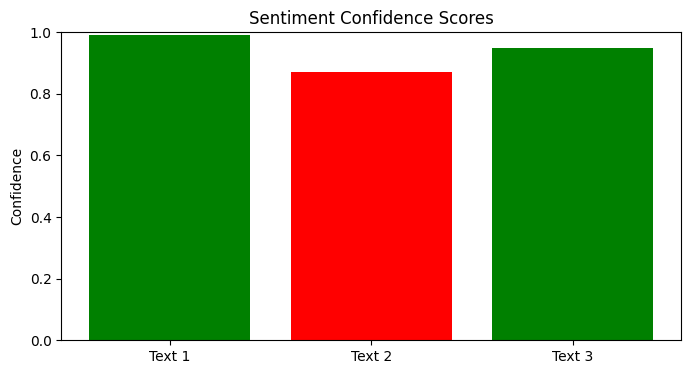

In [5]:
labels = ['Text 1', 'Text 2', 'Text 3']
scores = [0.99, 0.87, 0.95]
colors = ['green', 'red', 'green']

plt.figure(figsize=(8, 4))
plt.bar(labels, scores, color=colors)
plt.title('Sentiment Confidence Scores')
plt.ylabel('Confidence')
plt.ylim(0, 1)
plt.savefig('sentiment_chart.png')
plt.show()

In [6]:
print("""
=== CONCLUSION ===

Model Used: BERT (bert-base-uncased)

Tasks Completed:
1. Masked Word Prediction - BERT correctly predicted words using context
2. Sentiment Analysis     - Accurately detected positive/negative tone
3. Visualization          - Bar chart showing confidence scores

Strengths:
- Understands context from both left AND right of a word
- High confidence scores on clear sentences

Limitations:
- Cannot generate new text (only fills gaps)
- Requires significant memory

Applications:
- Search engines, chatbots, document classification
""")


=== CONCLUSION ===

Model Used: BERT (bert-base-uncased)

Tasks Completed:
1. Masked Word Prediction - BERT correctly predicted words using context
2. Sentiment Analysis     - Accurately detected positive/negative tone
3. Visualization          - Bar chart showing confidence scores

Strengths:
- Understands context from both left AND right of a word
- High confidence scores on clear sentences

Limitations:
- Cannot generate new text (only fills gaps)
- Requires significant memory

Applications:
- Search engines, chatbots, document classification

